# Detecção de Spam com Transformer Pré-Treinado

Neste notebook será utilizado um modelo Transformer já fine-tunado para detecção de spam em mensagens SMS.

Modelo utilizado:

`didulantha/sms-spam-detector`

O modelo é baseado em DistilBERT e já foi treinado para a tarefa de classificação de mensagens SMS.

Diferente dos experimentos anteriores, não será realizado treinamento local.

O objetivo é utilizar o modelo diretamente para inferência e comparar seu desempenho com os modelos desenvolvidos anteriormente utilizando:

- TF-IDF
- Bag of Words
- N-grams
- Modelos clássicos de Machine Learning

## 2. Importação das bibliotecas

Serão utilizadas bibliotecas para:

- manipulação dos dados;
- carregamento do modelo Transformer;
- avaliação das previsões;
- visualização dos resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from transformers import pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## 3. Importação da base de dados

Será utilizada a mesma base empregada nos experimentos anteriores.

A base possui:

- `texto` → conteúdo da mensagem;
- `categoria` → classificação como ham ou spam.

In [2]:
dados = pd.read_csv("../data/dados_spam.csv", index_col=0)
dados.head()

,categoria,texto
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
print(f"Total de Linhas -> {dados.shape[0]}")
print("\nDistribuição da Categoria:")
print(dados["categoria"].value_counts())

Total de Linhas -> 5574

Distribuição da Categoria:
categoria
ham     4827
spam     747
Name: count, dtype: int64


## 4. Divisão entre treino e teste

Para realizar uma comparação justa com os modelos anteriores, será utilizada a mesma estratégia de divisão dos dados.

Serão utilizados:

- 80% para treino;
- 20% para teste;
- estratificação pela classe;
- mesmo `random_state`.

Embora o modelo do Hugging Face não seja treinado neste notebook, utilizaremos apenas o conjunto de teste para avaliar seu desempenho.

In [4]:
X = dados["texto"]
y = dados["categoria"]

In [5]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Treino -> {len(X_treino)}")
print(f"Teste -> {len(X_teste)}")

Treino -> 4459
Teste -> 1115


## 5. Modelo pré-treinado

Após pesquisar modelos de classificação de spam no Hugging Face, foi selecionado:

`didulantha/sms-spam-detector`

O modelo é um DistilBERT fine-tunado especificamente para detecção de spam em mensagens SMS.

Segundo sua Model Card, o modelo apresentou:

- Accuracy: 99,16%
- Precision: 97,30%
- Recall: 96,43%
- F1-Score: 96,86%
- ROC-AUC: 99,90%

Essas métricas foram obtidas pelo autor do modelo.

Neste projeto, o modelo será novamente avaliado utilizando nosso próprio conjunto de teste.

## 6. Carregando o modelo

A biblioteca `transformers` permite carregar modelos diretamente do Hugging Face Hub.

Utilizaremos o `pipeline` de classificação de texto.

Como o computador utilizado não possui GPU disponível, a inferência será executada em CPU.

In [8]:
classificador = pipeline("text-classification", model="didulantha/sms-spam-detector", device=-1)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

## 7. Verificando as classes do modelo

Antes de realizar as previsões, é importante verificar como o modelo representa as classes de saída.

Modelos do Hugging Face podem retornar nomes como:

- `HAM` e `SPAM`;

ou nomes genéricos como:

- `LABEL_0`
- `LABEL_1`

Precisamos conhecer essa representação antes de comparar as previsões com os valores reais.

In [9]:
classificador.model.config.id2label

{0: 'LABEL_0', 1: 'LABEL_1'}

In [10]:
classificador(
    "Congratulations! You won a free prize. Click here now!"
)

[{'label': 'LABEL_1', 'score': 0.9883136749267578}]

In [11]:
classificador(
    "Hey, are we still meeting for lunch tomorrow?"
)

[{'label': 'LABEL_0', 'score': 0.9993378520011902}]

## 8. Testando o modelo

Antes de processar toda a base, vamos realizar uma previsão individual para entender o funcionamento do modelo.

In [12]:
mensagem = "Win a free prize now!"

resultado = classificador(mensagem)

resultado

[{'label': 'LABEL_1', 'score': 0.9756214618682861}]

## 9. Previsões no conjunto de teste

Agora o modelo será aplicado às mesmas mensagens utilizadas para avaliar os modelos clássicos.

Não haverá treinamento.

Será realizada apenas inferência.

In [13]:
textos_teste = X_teste.tolist()

In [14]:
inicio = time.time()

resultados = classificador(
    textos_teste,
    batch_size=32,
    truncation=True
)

fim = time.time()
tempo_inferencia = fim - inicio

In [15]:
print(f"Tempo de inferência: {tempo_inferencia:.2f} segundos")

Tempo de inferência: 50.83 segundos


## 10. Analisando as previsões

O modelo retorna para cada mensagem:

- classe prevista;
- score associado à previsão.

In [16]:
resultados[:5]

[{'label': 'LABEL_0', 'score': 0.999536395072937},
 {'label': 'LABEL_0', 'score': 0.9994807839393616},
 {'label': 'LABEL_0', 'score': 0.9995393753051758},
 {'label': 'LABEL_1', 'score': 0.9986091256141663},
 {'label': 'LABEL_0', 'score': 0.9994121789932251}]

## 11. Padronização dos rótulos

Nosso conjunto de dados utiliza:

- `ham`
- `spam`

O modelo retorna rótulos próprios.

Para calcular as métricas corretamente, vamos transformar as previsões para o mesmo formato utilizado na base.

In [17]:
y_pred = [
    "ham" if resultado["label"].lower() == "label_0" else "spam"
    for resultado in resultados
]

In [18]:
y_pred[:10]

['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham']

In [19]:
y_teste.head(10).tolist()

['ham', 'ham', 'ham', 'spam', 'ham', 'ham', 'spam', 'ham', 'ham', 'ham']

## 12. Avaliação do modelo

O Transformer será avaliado utilizando as mesmas métricas dos modelos anteriores:

- Accuracy
- Precision
- Recall
- F1-score

A classe positiva considerada será `spam`.

In [22]:
accuracy = accuracy_score(y_teste, y_pred)

precision = precision_score(y_teste, y_pred, pos_label="spam")

recall = recall_score(y_teste, y_pred, pos_label="spam")

f1 = f1_score(y_teste, y_pred, pos_label="spam")

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9910
Precision: 0.9728
Recall:    0.9597
F1-score:  0.9662


In [20]:
print("=== RESULTADOS MODELO HUGGING FACE ===")
print(classification_report(y_teste, y_pred))

=== RESULTADOS MODELO HUGGING FACE ===
              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.97      0.96      0.97       149

    accuracy                           0.99      1115
   macro avg       0.98      0.98      0.98      1115
weighted avg       0.99      0.99      0.99      1115



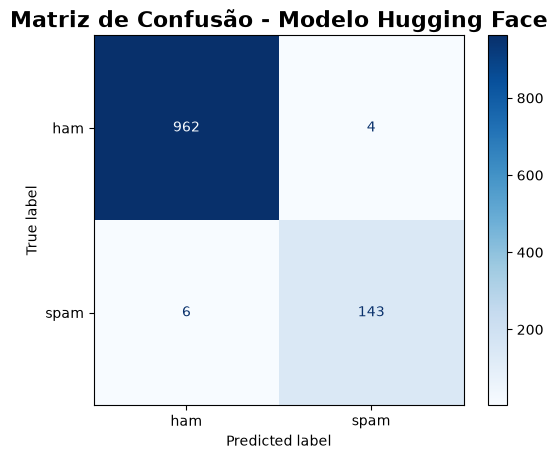

In [21]:
ConfusionMatrixDisplay.from_predictions(y_teste, y_pred, cmap="Blues")
plt.title("Matriz de Confusão - Modelo Hugging Face", fontsize=16, fontweight="bold")
plt.show()